##**1. Setup & Load**

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv('cleaned_data_fraud.csv')
df

,step,customer,age,gender,merchant,category,amount,fraud
0,0,C1093826151,4,M,M348934600,es_transportation,4.55,0
1,0,C352968107,2,M,M348934600,es_transportation,39.68,0
2,0,C2054744914,4,F,M1823072687,es_transportation,26.89,0
3,0,C1760612790,3,M,M348934600,es_transportation,17.25,0
4,0,C757503768,5,M,M348934600,es_transportation,35.72,0
...,...,...,...,...,...,...,...,...
594638,179,C1753498738,3,F,M1823072687,es_transportation,20.53,0
594639,179,C650108285,4,F,M1823072687,es_transportation,50.73,0
594640,179,C123623130,2,F,M349281107,es_fashion,22.44,0
594641,179,C1499363341,5,M,M1823072687,es_transportation,14.46,0


##**2. Split Data**

In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Train-test spilt

X = df.drop(columns=['fraud'])
y = df['fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Group-level statistics training set only
train_df = X_train.copy()
train_df['fraud'] = y_train

print("Train DataFrame Head:")
print(train_df.head())
print("\nTrain DataFrame Shape:")
print(train_df.shape)

Train DataFrame Head:
        step     customer age gender     merchant           category  amount  \
296209    97  C2008428493   2      F  M1823072687  es_transportation   19.01   
329958   107   C109634232   2      F   M348934600  es_transportation   26.98   
394447   125  C1621267054   2      F  M1823072687  es_transportation   22.60   
588673   178  C1275518867   5      F   M348934600  es_transportation    7.25   
139286    49   C471003383   3      F  M1823072687  es_transportation   18.42   

        fraud  
296209      0  
329958      0  
394447      0  
588673      0  
139286      0  

Train DataFrame Shape:
(475714, 8)


##**3. Target Based Riks Encoding**

In [10]:
#Credit Risk Score

category_risk = train_df.groupby('category')['fraud'].mean()
X_train['category_risk_score'] = X_train['category'].map(category_risk)
X_test['category_risk_score'] = X_test['category'].map(category_risk)

In [13]:
#Merchant Risk Score
merchant_risk = train_df.groupby('merchant')['fraud'].mean()
X_train['merchant_risk_score'] = X_train['merchant'].map(merchant_risk)
X_test['merchant_risk_score'] = X_test['merchant'].map(merchant_risk)

In [14]:
#Fill Unseen Categories/Merchants in the rest set wiht the global fraud rate
global_fraud_rate = train_df['fraud'].mean()
X_test['category_risk_score'] = X_test['category_risk_score'].fillna(global_fraud_rate)
X_test['merchant_risk_score'] = X_test['merchant_risk_score'].fillna(global_fraud_rate)

print(f"Unseen merchants in test set (filled with global fraud rate): "
      f"{(~X_test['merchant'].isin(merchant_risk.index)).sum()}")
print(f"Unseen categories in test set (filled with global fraud rate): "
      f"{(~X_test['category'].isin(category_risk.index)).sum()}")

Unseen merchants in test set (filled with global fraud rate): 0
Unseen categories in test set (filled with global fraud rate): 0


### Target-Based Risk Encoding — Category & Merchant (Interpretation)

**Interpretation**: This is expected given the dataset's structure — with
only 15 unique categories and a limited, fixed pool of merchants across
594,643 transactions, an 80/20 stratified split leaves virtually no
chance of a category or merchant appearing exclusively in the test set.
This confirms the risk encodings (`category_risk_score`,
`merchant_risk_score`) are fully populated from actual training-set
statistics, with no reliance on the global fraud rate fallback.

**Implication**: The fallback logic (`fillna(global_fraud_rate)`) remains
in the code as a safeguard for robustness — relevant if this pipeline
were applied to new, unseen merchants/categories in a production
setting — but did not affect this particular train-test split.

## **4. Amount Transformation & Custoomer Relative Features**

In [15]:
X_train['amount_log'] = np.log1p(X_train['amount'])
X_test['amount_log'] = np.log1p(X_test['amount'])

customer_avg_amount = train_df.groupby('customer')['amount'].mean()
customer_txn_count = train_df.groupby('customer').size()

X_train['customer_avg_amount'] = X_train['customer'].map(customer_avg_amount)
X_test['customer_avg_amount'] = X_test['customer'].map(customer_avg_amount)

X_train['customer_txn_count'] = X_train['customer'].map(customer_txn_count)
X_test['customer_txn_count'] = X_test['customer'].map(customer_txn_count)

global_avg_amount = X_train['amount'].mean()
X_test['customer_avg_amount'] = X_test['customer_avg_amount'].fillna(global_avg_amount)
X_test['customer_txn_count'] = X_test['customer_txn_count'].fillna(0)

X_train['amount_vs_avg_ratio'] = X_train['amount'] / X_train['customer_avg_amount']
X_test['amount_vs_avg_ratio'] = X_test['amount'] / X_test['customer_avg_amount']

print(f"New customers in test set (not seen in training): "
      f"{(~X_test['customer'].isin(customer_avg_amount.index)).sum()}")

New customers in test set (not seen in training): 0


### Amount Transformation & Customer-Relative Features (Interpretation)

**Interpretation**: Consistent with the category/merchant finding in
Section 2 — with only 4,112 unique customers spread across 594,643
transactions (an average of ~145 transactions per customer), an 80/20
stratified split leaves almost no chance of a customer appearing
exclusively in the test set. This confirms `customer_avg_amount` and
`customer_txn_count` are fully populated from real training-set
statistics, not fallback values.

**Implication**: The fallback logic (`fillna(global_avg_amount)`,
`fillna(0)`) remains in the code as a safeguard for production scenarios
involving genuinely new customers, but had no effect on this particular
split.

##**5. Standart Categorical Encoding - Age and Gender**

In [16]:
X_train = pd.get_dummies(X_train, columns=['age', 'gender'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['age', 'gender'], drop_first=True)

# Ensure train/test have identical columns after one-hot encoding
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)


##**6. Drop Raw Columns No Longer Needed**

In [17]:
cols_to_drop = ['step', 'customer', 'category', 'merchant', 'amount']

X_train_final = X_train.drop(columns=cols_to_drop)
X_test_final = X_test.drop(columns=cols_to_drop)

print("Final feature columns:", X_train_final.columns.tolist())
print("Train shape:", X_train_final.shape)
print("Test shape:", X_test_final.shape)

Final feature columns: ['category_risk_score', 'merchant_risk_score', 'amount_log', 'customer_avg_amount', 'customer_txn_count', 'amount_vs_avg_ratio', 'age_1', 'age_2', 'age_3', 'age_4', 'age_5', 'age_6', 'age_U', 'gender_F', 'gender_M', 'gender_U']
Train shape: (475714, 16)
Test shape: (118929, 16)


In [18]:
print('gender_E' in X_train_final.columns)
print([col for col in X_train_final.columns if 'gender' in col])

False
['gender_F', 'gender_M', 'gender_U']


### Drop Raw Columns No Longer Needed (Interpretation)


**Interpretation**: All raw high-cardinality identifiers (`customer`,
`merchant`, `category`) and the temporally weak `step` feature have been
successfully removed, replaced entirely by their engineered counterparts.
The feature set is now fully numeric and model-ready — no further
encoding is required before modeling.

**Note**: `gender_E` does not appear as a dummy column, meaning `E` was
used as the reference category dropped by `drop_first=True` during
one-hot encoding. This is expected behavior and does not indicate missing
data.

##**7. Correlation Sanity Check On Engineered Numeric Features**

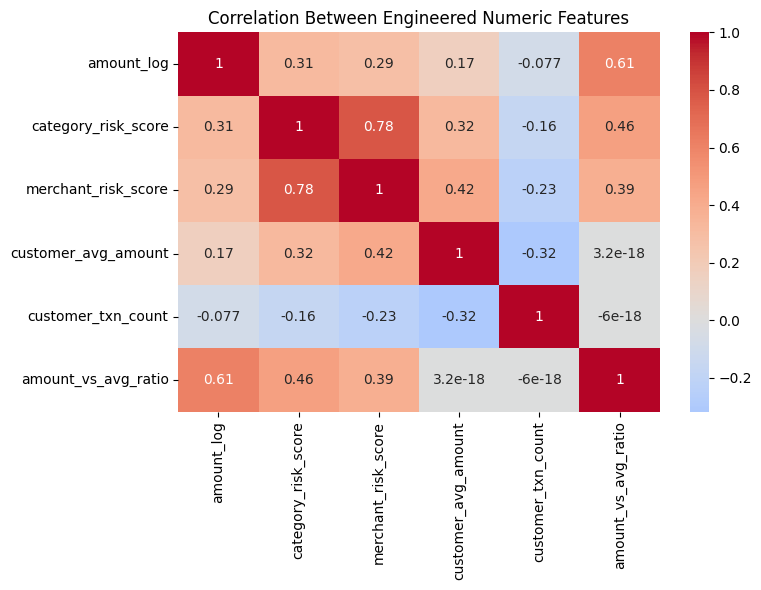

In [22]:
import os

corr_features = ['amount_log', 'category_risk_score', 'merchant_risk_score',
                  'customer_avg_amount', 'customer_txn_count', 'amount_vs_avg_ratio']

plt.figure(figsize=(8, 6))
sns.heatmap(X_train_final[corr_features].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Between Engineered Numeric Features')
plt.tight_layout()

# Create the directory if it doesn't exist
output_dir = 'outputs/figures/'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, '08_feature_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()

### Correlation Sanity Check (Interpretation)

**Result**: `category_risk_score` and `merchant_risk_score` show a strong
correlation of **0.78** — the highest pairwise correlation in the matrix,
confirming they carry substantially overlapping signal. `amount_log` and
`amount_vs_avg_ratio` also correlate moderately (0.61), which is expected
since the ratio is mathematically derived from amount. Most other pairs
show weak-to-moderate correlations (0.17–0.46), and `customer_txn_count`
shows mild negative correlations with several features (e.g. -0.32 with
`customer_avg_amount`), suggesting customers with more frequent
transactions tend to have somewhat lower average amounts.

**Interpretation**: The 0.78 correlation between category and merchant
risk scores directly confirms what EDA Sections 4 and 7 already
suggested — high-risk merchants are concentrated within high-risk
categories, so these two features are reinforcing rather than fully
independent signals. This is not surprising given the data structure
(each merchant operates within a specific category), but it's worth
flagging explicitly.

**Modeling Implications**:
- No pair reaches a correlation extreme enough (e.g. >0.9) to warrant
  dropping one of the two features outright — both `category_risk_score`
  and `merchant_risk_score` still carry some distinct information (0.78,
  not 1.0), and merchant-level detail is more granular than category-level.
- For **tree-based models** (Random Forest, XGBoost) — the planned
  primary models — this level of correlation is generally not
  problematic, as these models handle correlated features reasonably
  well and will naturally favor whichever is more discriminative at
  each split.
- For the **Logistic Regression baseline**, this correlation is worth
  monitoring — if coefficient signs or magnitudes look unstable, this
  multicollinearity is the likely cause. This can be noted as a known
  limitation of the baseline model rather than something that needs
  fixing before proceeding.
- No changes to the feature set are needed at this stage — proceed to
  modeling with all 16 features intact.

##**8. Save Outputs For The Next Notebook**

In [24]:
import os

# Create the 'data' directory if it doesn't exist
os.makedirs('data', exist_ok=True)

X_train_final.to_csv('data/X_train_final.csv', index=False)
X_test_final.to_csv('data/X_test_final.csv', index=False)
y_train.to_csv('data/y_train.csv', index=False)
y_test.to_csv('data/y_test.csv', index=False)

print("Feature engineering complete. Files saved to /data for modeling stage.")

Feature engineering complete. Files saved to /data for modeling stage.


In [25]:
X_test.shape

(118929, 7)

In [27]:
X_train.shape

(475714, 7)

In [29]:
y_train.shape

(475714,)

In [30]:
y_test.shape

(118929,)